
# Assignment 1: Assessing Bicycle Lane Quality

## Team 1: Raina Allkoçi, Xinran Zhi, Rahma El Sayed

**Objective:** Classify bicycle-lane conditions as smooth or bumpy using smartphone accelerometer, gyroscope, and gravity measurements.

## 1. Data Loading and Understanding

### 1.1 Imports and dataset location

In [1]:
import sys
from pathlib import Path
from zipfile import ZipFile

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

print("Python:", sys.version.split()[0])
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Matplotlib:", matplotlib.__version__)


working_dir = Path.cwd()
project_folder = (working_dir if (working_dir / "raw data file").is_dir()
                  else working_dir.parent)
data_folder = project_folder / "raw data file"
if not data_folder.is_dir():
    raise FileNotFoundError(f"Raw data folder not found: {data_folder}")

zip_files = sorted(data_folder.rglob("*.zip"))
if not zip_files:
    raise FileNotFoundError(f"No ZIP recordings found in {data_folder}")
print("ZIP recordings found:", len(zip_files))

Python: 3.12.12
NumPy: 2.5.3
Pandas: 3.0.5
Matplotlib: 3.11.1
ZIP recordings found: 30


### 1.2 Load and combine the sensor recordings

For each ZIP, load the three requested sensors and verify that their timestamps align before combining them. Participant, road-condition, and recording identifiers are retained. Original ZIP files remain unchanged.

In [2]:
def load_recording(zip_path):

    """Read one ZIP recording and align its three sensor files by timestamp."""
    
    with ZipFile(zip_path, "r") as archive:
        with archive.open("Accelerometer.csv") as file:
            acc = pd.read_csv(file)
        with archive.open("Gyroscope.csv") as file:
            gyro = pd.read_csv(file)
        with archive.open("Gravity.csv") as file:
            gravity = pd.read_csv(file)

    if not (acc["time"].equals(gyro["time"])
            and acc["time"].equals(gravity["time"])):
        raise ValueError(f"Sensor timestamps do not match: {zip_path}")

    return pd.DataFrame({
        "time": acc["time"],
        "seconds_elapsed": acc["seconds_elapsed"],
        "acc_x": acc["x"], "acc_y": acc["y"], "acc_z": acc["z"],
        "gyro_x": gyro["x"], "gyro_y": gyro["y"], "gyro_z": gyro["z"],
        "gravity_x": gravity["x"], "gravity_y": gravity["y"],
        "gravity_z": gravity["z"]
    })

In [3]:
all_recordings = []
for zip_path in zip_files:
    participant = zip_path.parent.parent.name
    road_condition = zip_path.parent.name.lower()

    recording = load_recording(zip_path)
    recording["participant"] = participant
    recording["road_condition"] = road_condition
    #Unique recording ID relative to the raw-data folder.
    recording["recording_id"] = zip_path.relative_to(data_folder).as_posix()
    all_recordings.append(recording)

combined_df = pd.concat(all_recordings, ignore_index=True)
print("Combined dataset shape:", combined_df.shape)
print("Number of recordings:", combined_df["recording_id"].nunique())
print("Number of participants:", combined_df["participant"].nunique())
display(combined_df.head())

Combined dataset shape: (420506, 14)
Number of recordings: 30
Number of participants: 3


,time,seconds_elapsed,acc_x,acc_y,acc_z,gyro_x,gyro_y,gyro_z,gravity_x,gravity_y,gravity_z,participant,road_condition,recording_id
0,1789734532680360400,0.053360,0.525098,0.198844,-0.317852,0.576124,-0.386222,-0.125969,-0.723667,4.737252,8.556000,participant_1,bumpy,participant_1/bumpy/p1_bumpy_1.zip
1,1789734532690368800,0.063369,0.499797,0.149029,-0.292189,0.611401,-0.374717,-0.186475,-0.698366,4.787067,8.530338,participant_1,bumpy,participant_1/bumpy/p1_bumpy_1.zip
2,1789734532700376800,0.073377,0.565957,0.457386,0.393400,0.628788,-0.322669,-0.266257,-0.679233,4.838439,8.502855,participant_1,bumpy,participant_1/bumpy/p1_bumpy_1.zip
3,1789734532710384600,0.083385,0.593435,0.282436,0.727975,0.666647,-0.203669,-0.363661,-0.671845,4.891135,8.473240,participant_1,bumpy,participant_1/bumpy/p1_bumpy_1.zip
4,1789734532720392700,0.093393,0.555283,-0.118405,0.713513,0.723867,-0.047215,-0.479859,-0.681876,4.947210,8.439819,participant_1,bumpy,participant_1/bumpy/p1_bumpy_1.zip


### 1.3 Dataset overview and quality checks

Summarize recording counts and durations. The road-condition labels apply to **the whole recording**, which means that recordings labeled 'bumpy' can still contain smooth sections.

In [4]:
recording_counts = (
    combined_df.groupby(["participant", "road_condition"])["recording_id"]
    .nunique().unstack(fill_value=0)
)
recording_durations = (
    combined_df.groupby(["participant", "road_condition", "recording_id"])
    ["seconds_elapsed"].agg(lambda values: values.max() - values.min())
    .reset_index(name="duration_seconds")
)
duration_summary = (
    recording_durations.groupby("road_condition")["duration_seconds"]
    .agg(["count", "sum", "mean", "min", "max"])
)

print("Recording counts by participant and condition:")
display(recording_counts)
print("Recording durations (seconds) by condition:")
display(duration_summary)

Recording counts by participant and condition:


road_condition,bumpy,smooth
participant,,
participant_1,7,3
participant_2,7,3
participant_3,6,4


Recording durations (seconds) by condition:


,count,sum,mean,min,max
road_condition,,,,,
bumpy,20,2720.861194,136.043060,34.333133,265.051933
smooth,10,1486.669629,148.666963,40.704864,292.451381


## 2. Exploratory Data Analysis

Compare acceleration magnitude from smooth and bumpy recordings, and visualize possible phone-handling artifacts at their boundaries. Magnitude summarizes movement, but peaks alone do not establish the road condition.

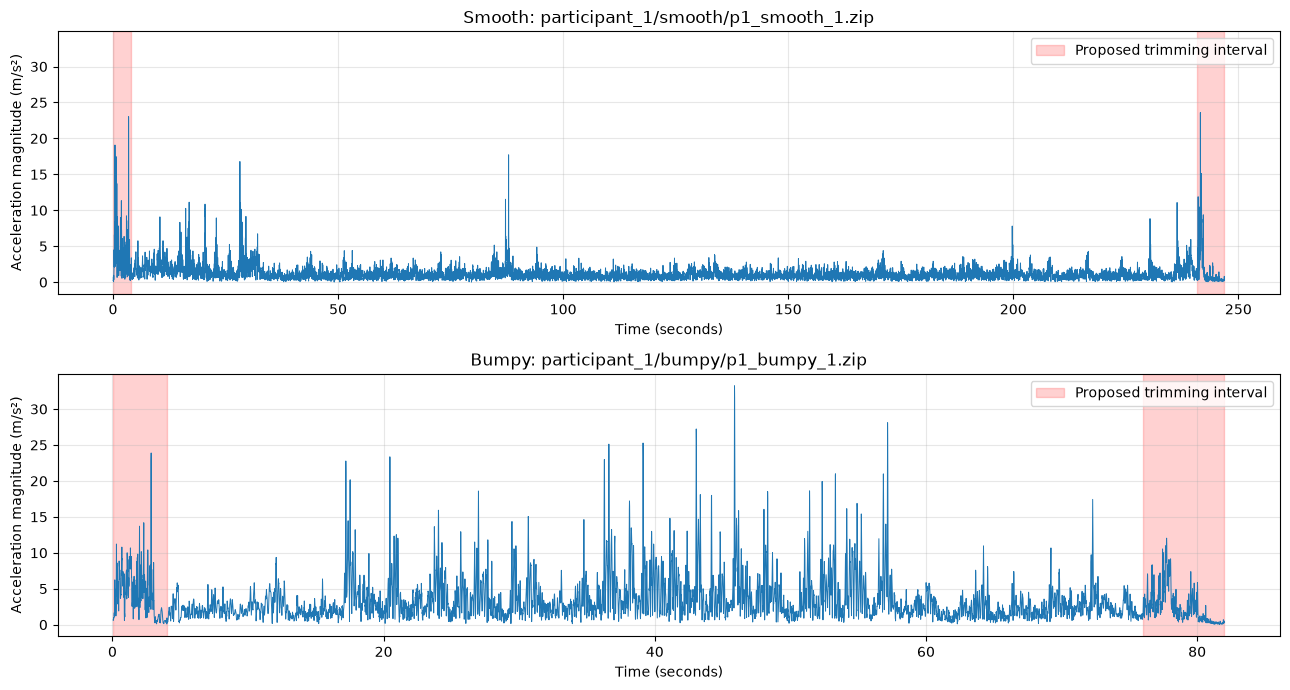

In [5]:
#keep original x, y, z axes
#magnitude combines their overall acceleration.
combined_df["acc_magnitude"] = np.sqrt(
    combined_df["acc_x"]**2 + combined_df["acc_y"]**2 + combined_df["acc_z"]**2
)

participant = "participant_1"
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharey=True)

for ax, condition in zip(axes, ["smooth", "bumpy"]):
    subset = combined_df.loc[
        (combined_df["participant"] == participant)
        & (combined_df["road_condition"] == condition)
    ]
    if subset.empty:
        raise ValueError(f"No {condition} recording found for {participant}")
    recording_id = subset["recording_id"].iloc[0]
    recording = subset.loc[subset["recording_id"] == recording_id]

    ax.plot(recording["seconds_elapsed"], recording["acc_magnitude"], linewidth=0.7)
    start, end = recording["seconds_elapsed"].min(), recording["seconds_elapsed"].max()
    ax.axvspan(start, start + 4, color="red", alpha=0.18, label="Proposed trimming interval")
    ax.axvspan(end - 6, end, color="red", alpha=0.18)
    ax.set(title=f"{condition.capitalize()}: {recording_id}",
           ylabel="Acceleration magnitude (m/s²)", xlabel="Time (seconds)")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper right")
plt.tight_layout()
plt.show()



## 3. Data Preprocessing

### 3.1 Remove Phone-Handling Periods

The first 4 seconds and last 6 seconds of each recording are excluded to reduce artifacts caused by inserting and removing the smartphone from the back pocket.

The trimming procedure is applied independently to each recording, preserving the original raw data.

In [6]:
trim_start = 4  # seconds
trim_end = 6    # seconds
trimmed_recordings = []

for recording_id, recording in combined_df.groupby("recording_id", sort=False):
    start = recording["seconds_elapsed"].min()
    end = recording["seconds_elapsed"].max()
    if start + trim_start >= end - trim_end: #if it's too short
        raise ValueError(f"Recording too short to trim: {recording_id}")
    trimmed_recordings.append(recording.loc[
        (recording["seconds_elapsed"] >= start + trim_start)
        & (recording["seconds_elapsed"] <= end - trim_end)
    ].copy())

trimmed_df = pd.concat(trimmed_recordings, ignore_index=True)
print(f"Measurements: {len(combined_df):,} before -> {len(trimmed_df):,} after trimming")
print("Recordings retained:", trimmed_df["recording_id"].nunique())
assert trimmed_df["recording_id"].nunique() == combined_df["recording_id"].nunique()


Measurements: 420,506 before -> 390,501 after trimming
Recordings retained: 30



## 4. Feature Engineering and Extraction

### 4.1 Divide the retained recordings into windows

Divide each trimmed recording into non-overlapping 2-second intervals (about 200 samples at 100 Hz). All retained cycling data are considered, not just the interval used in the example plot below. Window IDs restart for each recording.

In [7]:
window_duration = 2  # seconds
windowed_recordings = []
for recording_id, recording in trimmed_df.groupby("recording_id", sort=False):
    recording = recording.sort_values("seconds_elapsed").copy()
    first_time = recording["seconds_elapsed"].iloc[0]
    recording["window_id"] = (
        (recording["seconds_elapsed"] - first_time) // window_duration
    ).astype(int)
    windowed_recordings.append(recording)

windowed_df = pd.concat(windowed_recordings, ignore_index=True)
print("Windows before incomplete-window filtering:",
      windowed_df.groupby(["recording_id", "window_id"]).ngroups)


Windows before incomplete-window filtering: 1969


### 4.2 Visualize the window boundaries

The following 20-second view is **illustrative only**. Its shaded windows use the same IDs and boundaries as the full-recording window assignment above. Change `example_id` to examine another recording.

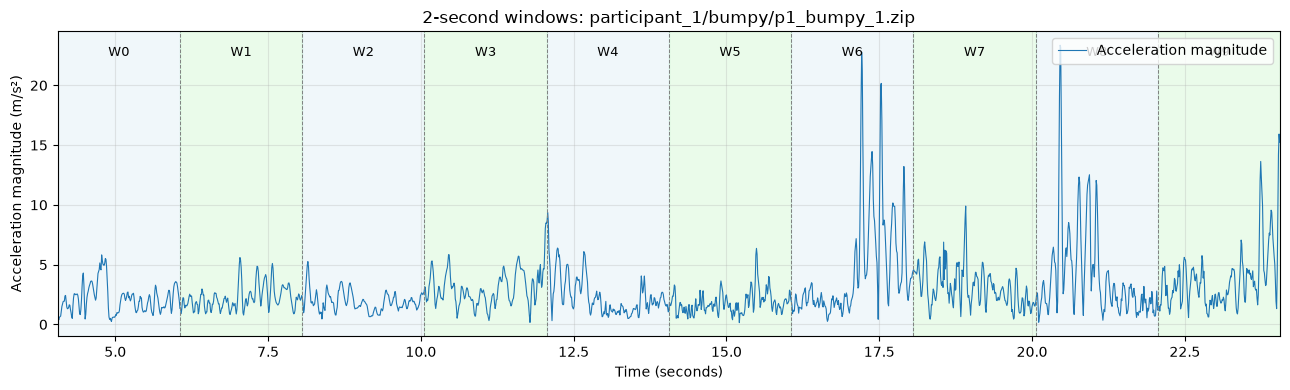

In [8]:
example_id = trimmed_df["recording_id"].iloc[0]
example = windowed_df.loc[windowed_df["recording_id"] == example_id].copy()
if example.empty: #if typed wrong 
    raise ValueError(f"Recording not found: {example_id}")

segment_start = example["seconds_elapsed"].min()  #starts at W0
segment_end = min(segment_start + 20, example["seconds_elapsed"].max())
segment = example.loc[example["seconds_elapsed"].between(segment_start, segment_end)]

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(segment["seconds_elapsed"], segment["acc_magnitude"],
        linewidth=0.8, label="Acceleration magnitude")

for window_id, window in segment.groupby("window_id", sort=True):
    #actual bounds are anchored to the first sample of the trimmed recording.
    start = example["seconds_elapsed"].min() + window_id * window_duration
    end = start + window_duration
    left, right = max(start, segment_start), min(end, segment_end)
    if left >= right:
        continue
    ax.axvspan(left, right, alpha=0.18,
               color="lightblue" if window_id % 2 == 0 else "lightgreen")
    ax.axvline(left, linestyle="--", linewidth=0.7, color="gray")
    #label only complete visible windows to avoid edge overlaps.
    if start >= segment_start and end <= segment_end:
        ax.text((start + end) / 2, 0.93, f"W{window_id}",
                ha="center", va="center", fontsize=9,
                transform=ax.get_xaxis_transform())

ax.set(xlim=(segment_start, segment_end),
       title=f"2-second windows: {example_id}",
       xlabel="Time (seconds)", ylabel="Acceleration magnitude (m/s²)")
ax.grid(True, alpha=0.3)
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()


### 4.3 Check window sizes

At 100 Hz, each 2-second window should contain approximately 200 measurements. Windows containing fewer than 180 measurements (90% of the expected samples) are excluded to ensure that features are extracted from intervals of comparable duration.

In [9]:
window_sizes = (
    windowed_df.groupby(["recording_id", "window_id"])
    .size().reset_index(name="n_samples")
)
print("Samples per window (before filtering):")
display(window_sizes["n_samples"].describe())

min_samples = 180
valid_windows = window_sizes.loc[
    window_sizes["n_samples"] >= min_samples, ["recording_id", "window_id"]
]
windowed_df = windowed_df.merge(
    valid_windows, on=["recording_id", "window_id"], how="inner"
)
print("Windows retained:", len(valid_windows))
print("Recordings retained:", windowed_df["recording_id"].nunique())


Samples per window (before filtering):


count    1969.000000
mean      198.324530
std        13.650613
min        24.000000
25%       200.000000
50%       200.000000
75%       200.000000
max       201.000000
Name: n_samples, dtype: float64

Windows retained: 1941
Recordings retained: 30


### 4.4 Feature Extraction

Statistical features are extracted from each retained 2-second window using accelerometer, gyroscope, and gravity measurements. Mean and standard deviation describe the average movement and variability, while maximum magnitude and root mean square (RMS) capture strong movements and overall signal intensity.


**Note:** The `road_condition` value is inherited from the **whole recording**, not independently verified for each window.

In [10]:
#acceleration and gyroscope magnitudes
windowed_df["acc_magnitude"] = np.sqrt(
    windowed_df["acc_x"]**2
    + windowed_df["acc_y"]**2
    + windowed_df["acc_z"]**2
)

windowed_df["gyro_magnitude"] = np.sqrt(
    windowed_df["gyro_x"]**2
    + windowed_df["gyro_y"]**2
    + windowed_df["gyro_z"]**2
)

#sensor signals used for feature extraction
sensor_columns = [
    "acc_x", "acc_y", "acc_z", "acc_magnitude",
    "gyro_x", "gyro_y", "gyro_z", "gyro_magnitude",
    "gravity_x", "gravity_y", "gravity_z"
]

#mean and standard deviation for each window
features_df = (
    windowed_df.groupby(
        ["recording_id", "window_id"]
    )[sensor_columns]
    .agg(["mean", "std"])
)

features_df.columns = [
    f"{sensor}_{statistic}"
    for sensor, statistic in features_df.columns
]

features_df = features_df.reset_index()

#additional magnitude features
magnitude_features = (
    windowed_df.groupby(
        ["recording_id", "window_id"]
    )
    .agg(
        acc_magnitude_max=("acc_magnitude", "max"),
        acc_magnitude_rms=(
            "acc_magnitude",
            lambda x: np.sqrt(np.mean(x**2))
        ),
        gyro_magnitude_max=("gyro_magnitude", "max"),
        gyro_magnitude_rms=(
            "gyro_magnitude",
            lambda x: np.sqrt(np.mean(x**2))
        )
    )
    .reset_index()
)

#save recording information and road-condition labels
window_info = (
    windowed_df.groupby(
        ["recording_id", "window_id"]
    )
    .agg(
        participant=("participant", "first"),
        road_condition=("road_condition", "first"),
        window_start=("seconds_elapsed", "min"),
        window_end=("seconds_elapsed", "max")
    )
    .reset_index()
)

#combine all features and recording information
features_df = (
    features_df
    .merge(
        magnitude_features,
        on=["recording_id", "window_id"]
    )
    .merge(
        window_info,
        on=["recording_id", "window_id"]
    )
)

In [11]:

#verify the feature dataset
print("Total windows:", len(features_df))
print("Numerical features:", 26)
print("Recordings:", features_df["recording_id"].nunique())
print("Missing values:", features_df.isnull().sum().sum())


window_summary = (
    features_df.groupby(["participant", "road_condition"])
    .size()
    .unstack(fill_value=0)
)

print("\nWindows per participant and road condition:")
display(window_summary)


#select representative features from all three sensors
display_columns = [
    "participant",
    "road_condition",
    "window_id",
    "acc_magnitude_mean",
    "acc_magnitude_std",
    "gyro_magnitude_std",
    "gravity_z_mean"
]

#display one example window per participant and road condition
feature_preview = (
    features_df.groupby(
        ["participant", "road_condition"],
        sort=True
    )
    .head(1)[display_columns]
    .reset_index(drop=True)
)

print("Example feature vectors:")
display(feature_preview.round(3))

Total windows: 1941
Numerical features: 26
Recordings: 30
Missing values: 0

Windows per participant and road condition:


road_condition,bumpy,smooth
participant,,
participant_1,608,388
participant_2,295,104
participant_3,349,197


Example feature vectors:


,participant,road_condition,window_id,acc_magnitude_mean,acc_magnitude_std,gyro_magnitude_std,gravity_z_mean
0,participant_1,bumpy,0,2.129,1.195,0.595,-2.011
1,participant_1,smooth,0,1.698,1.059,0.279,-3.462
2,participant_2,bumpy,0,6.168,3.557,0.152,7.504
3,participant_2,smooth,0,1.606,1.114,0.733,1.658
4,participant_3,bumpy,0,1.789,0.700,0.264,0.695
5,participant_3,smooth,0,1.617,0.870,0.524,0.242


## Section 5: Preparing the Data for Machine Learning.